In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) #removes the limit on how many columns Pandas will display in your output
pd.set_option('display.max_rows', 100)  #increases the maximum number of rows pandas will display before truncating a DataFrame

In [3]:
activity = pd.read_csv(r'C:\Users\kusha\OneDrive\Desktop\My projects\Bellabeat case study\raw data\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\dailyActivity_merged.csv')
sleep = pd.read_csv(r'C:\Users\kusha\OneDrive\Desktop\My projects\Bellabeat case study\raw data\mturkfitbit_export_4.12.16-5.12.16\Fitabase Data 4.12.16-5.12.16\sleepDay_merged.csv')

## Data Audit 

In [4]:
print("ACTIVITY DATASET")
print("-" * 50)

print(activity.head())
print("\nShape:")
print(activity.shape)

print("\nData Types:")
print(activity.dtypes)

print("\nMissing Values:")
print(activity.isnull().sum())

print("\nDuplicate Rows:")
print(activity.duplicated().sum())

ACTIVITY DATASET
--------------------------------------------------
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  

In [5]:
print("SLEEP DATASET")
print("-" * 50)

print(sleep.head())
print("\nShape:")
print(sleep.shape)

print("\nData Types:")
print(sleep.dtypes)

print("\nMissing Values:")
print(sleep.isnull().sum())

print("\nDuplicate Rows:")
print(sleep.duplicated().sum())

SLEEP DATASET
--------------------------------------------------
           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed  
0             346  
1             407  
2             442  
3             367  
4             712  

Shape:
(413, 5)

Data Types:
Id                     int64
SleepDay              object
TotalSleepRecords      int64
TotalMinutesAsleep     int64
TotalTimeInBed         int64
dtype: object

Missing Values:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64



## Change log 
1- initial audit findings
'''daliyActvity_merged.csv
  -Dataset contains 940 rows and 15 columns.
  - No missing values detected.
  - No duplicate records detected.
  - ActivityDate stored as object data type and requires conversion to datetime format.'''

'''sleepDay_merged.csv
   -Dataset contains 413 rows and 5 columns.
   -No missing values detected.
   - 3 duplicate records detected.
   - SleepDay stored as object data type and requires conversion to datetime format.   '''

2- Duplicate Removal 
     - Identified 3 duplicates 
     - Verified that duplicates were exact matches across all coloumn 
     - Removed duplicate records to prevent inflation in sleep metrics 
     - Row count reduced from 413 to 410

3- Data Standardization
     > Activity Dataset: 
         - Converted ActivityDate from object to datetime 
     > Sleep Dataset
         - Converted SleepDay from object to datetime

4- Dataset Merge 
    - Created a date key in both datasets.
    - Merged activity and sleep data using Id and Date.
    - Used an inner join to retain records with both activity and sleep information.
    - Resulting dataset contains 410 observations and 26 variables.
    - No missing values or duplicate records were introduced during the merge.

##
Analysis log
1. Dataset Overview
   Activity Dataset
     - 940 observations
     - 15 variables
     - 33 unique users
     - Date range: April 12, 2016 – May 9, 2016
     - No missing values
     - No duplicate records
   Sleep Dataset
     - 413 observations initially
     - 5 variables
     - 24 unique users
     - Date range: April 12, 2016 – May 9, 2016
     - No missing values
     - 3 duplicate records identified and removed
     - Final row count: 410
3. User Coverage Findings
Finding 1
The activity dataset contains 33 users, while the sleep dataset contains only 24 users.

Interpretation
 -Not all Fitbit users tracked their sleep.
Business Implication
 -Users appear more likely to engage with activity tracking than sleep tracking.

3. Data Quality Findings
Finding 2
A dataset mismatch was discovered during the first merge attempt.

Evidence
 -The activity and sleep datasets came from different Fitbit extracts and had non-overlapping     date ranges.
Action Taken
- The incorrect activity dataset was replaced and revalidated.
Business Value
-Demonstrates proper data validation and quality assurance.

4. Activity Level Segmentation

Users were classified into three groups:
 -Activity Level	Definition
 -Low Active	< 5,000 steps
 - Moderately Active	5,000–10,000 steps
 - Highly Active	> 10,000 steps
Distribution
 -Activity Level    |	 Count
 -Moderately Active |    334
 -Highly Active	    |    303
 -Low Active	    |    226

Finding 3
- The majority of observations belong to the Moderate and Highly Active groups.
Business Implication
- Fitbit users in this sample are generally active and health-conscious.

Overall Activity Behavior
Finding 4
 - Average daily steps: 8,515 steps/day

Interpretation
- Users are moderately active and approach the commonly referenced 10,000-step target.

Finding 5
Average calories burned: 2,389 calories/day

Finding 6
Average active minutes:
Metric                |	Average
Very Active Minutes	  | 25
Fairly Active Minutes |	18
Lightly Active Minutes|	217

Interpretation
 -Most activity occurs in the light activity category.

Finding 7

Average sedentary time: 712 minutes/day ≈ 11.9 hours/day
Interpretation
 -Even active users spend substantial portions of their day sedentary.

Potential Bellabeat Opportunity
Encourage movement breaks and inactivity reminders.

Sleep Behavior Findings
Finding 8
Average sleep duration:6.99 hours/night

Interpretation
 -Users are very close to the commonly recommended 7 hours of sleep.

Finding 9

Average time spent in bed: 7.64 hours/night

Finding 10
Difference between time in bed and time asleep: 7.64 - 6.99 = 0.65 hours ≈ 39 minutes

Interpretation
 - Users spend approximately 39 minutes awake while in bed.

Potential Bellabeat Opportunity
Sleep quality and bedtime optimization features.

Activity vs Sleep Findings
Finding 11

Average sleep by activity level:

Activity Level	   | Sleep Hours
-Low Active	       |   7.57
-Moderately Active |   7.04
-Highly Active     |   6.60

Observation
Sleep duration decreases as activity level increases.

Finding 12: Total Steps vs Sleep Hours
Correlation coefficient : r= -0.19
Interpretation: 
    - Negative relationship
    - Very weak relationship
    - As step counts increase, sleep hours tend to decrease slightly
    - The relationship is not strong
Business Interpretation
- Sleep duration cannot be reliably predicted by daily step counts alone.

Finding 13: Very Active Minutes vs Sleep Hours
Correlation coefficient: r= -0.09
Interpretation: 
     -Extremely weak negative relationship
     -Essentially no meaningful relationship
Business Interpretation
 - Very active exercise time appears to have little association with sleep duration in this        dataset.

Finding 14- Users are most active on Saturday 
Interpretation:
    - Users reach their highest activity levels on Saturdays
Business Implication: 
     - Weekend fitness challenges and activity campaigns may receieve higher engagement.

Finding 15- Users are least active on Sunday
Interpretation: 
  - Activity drops significantly from Saturday to Sunday
Business Implication:
  - Bellabeat could encourage sunday activity through reminders, challenges or recovery focused     content.

Finding 16 - Users sleep the most on Sunday 
Interpretation: 
   - Users appear to use sunday as recovery day.
Business Implication:
   - Bellabeat could focus on recovery content.

Finding 17 - User sleep the least on Thursday
Interpretation: 
  - Sleep duration declines during the workweek and reaches its lowest point before the weekend.

Finding 18- Users appear to be most physically active on saturdays and obtain the most sleep on sundays, suggesting a weekend recovery pattern. 

Finding 19 - Users sleep approximatley 23 minutes longer on weekends(7.26 hrs) than on weekdays(6.88 hrs)
Interpretation: 
  - Users appear to recover sleep on weekends
Business Implication:
Bellabeat can emphasize:
  - Sleep reovery
  - Weekend wellness routines
  - Rest and recovery content

Finding 20 - Activity levels are similar across weekdays and weekends, with a minor difference of 127 steps.
Interpretation: 
  - Users maintain relatively consistent activity levels throughout the week
Business Implication:
 - Bellabeat should encourage activity everyday rather than focusing only on weekend or            weekdays excercise campaign

Finding 21- Sedentary time shows a moderate negative correlation with sleep duration(r= -0.60).
          - Among all activity related metrics analyzed, sedentary behaviour demonstrated the               stongest relationship with sleep duration.
          - Users who spend more time sedentary tend to sleep fewer hours.
Finding 22- Users spend an average 11.87 hours per day sedentary 

Finding 23 - Visual analysis of scatter plot confirms a clear negative relationship between                  sedentary hours and sleep hours.

Finding 24 - Approximately 76.6% of observations belong to users who are either: Moderately active or Highly active
Iterpretation: 
 - Most Fitbit users in this sample demonstrate moderarte to high level of physical activity
Business Implication:
 - The Fitbit user base appears health-councious and engaged in fitness tracking

Finding 25 - Approximately 23.4% of observation fall into low activity category. 
Interpretation: 
  - Nearly one quarter of observations represent users with fewer than 5000 daily steps.


In [6]:
sleep[sleep.duplicated()]

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
161,4388161847,5/5/2016 12:00:00 AM,1,471,495
223,4702921684,5/7/2016 12:00:00 AM,1,520,543
380,8378563200,4/25/2016 12:00:00 AM,1,388,402


In [7]:
sleep = sleep.drop_duplicates()
sleep.duplicated().sum()

np.int64(0)

In [8]:
activity['ActivityDate'] = pd.to_datetime(
    activity['ActivityDate']
)

sleep['SleepDay'] = pd.to_datetime(
    sleep['SleepDay']
)

C:\Users\kusha\AppData\Local\Temp\ipykernel_24448\3706440242.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['SleepDay'] = pd.to_datetime(


In [9]:
activity.info()
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes  

## Feature Engineering 

In [10]:
activity['DayOfWeek'] = activity['ActivityDate'].dt.day_name() #extracts day
activity['Month'] = activity['ActivityDate'].dt.month_name() #extract month 
activity['IsWeekend'] = activity['ActivityDate'].dt.dayofweek >= 5

In [11]:
activity[['ActivityDate', 
           'DayOfWeek', 
           'Month', 
            'IsWeekend']].head()

,ActivityDate,DayOfWeek,Month,IsWeekend
0,2016-04-12,Tuesday,April,False
1,2016-04-13,Wednesday,April,False
2,2016-04-14,Thursday,April,False
3,2016-04-15,Friday,April,False
4,2016-04-16,Saturday,April,True


## sleep hours 

In [12]:
sleep['SleepHours'] = round(sleep['TotalMinutesAsleep'] /60,2)
sleep['TimeInBedHours'] = round(sleep['TotalTimeInBed'] /60,2)

In [13]:
sleep[['TotalMinutesAsleep',
       'SleepHours',
       'TotalTimeInBed',
       'TimeInBedHours']].head()

,TotalMinutesAsleep,SleepHours,TotalTimeInBed,TimeInBedHours
0,327,5.45,346,5.77
1,384,6.40,407,6.78
2,412,6.87,442,7.37
3,340,5.67,367,6.12
4,700,11.67,712,11.87


In [14]:
activity['ActivityLevel'] = pd.cut( #used to bin (group) continuous numerical data into discrete categories (buckets)
    activity['TotalSteps'], #source coloumn
    bins = [0,5000,10000, np.inf],  #creates groups 
    labels = [
        'Low Active', 
        'Moderately Active', 
        'Highly Active'
    ]
)

In [15]:
activity['ActivityLevel'].value_counts()  # method in pandas is used to count the frequency of unique values within a Series or a DataFrame column

ActivityLevel
Moderately Active    334
Highly Active        303
Low Active           226
Name: count, dtype: int64

In [16]:
activity['Date'] = activity['ActivityDate'].dt.date
sleep['Date'] = sleep['SleepDay'].dt.date

In [17]:
activity[['ActivityDate','Date']].head()

,ActivityDate,Date
0,2016-04-12,2016-04-12
1,2016-04-13,2016-04-13
2,2016-04-14,2016-04-14
3,2016-04-15,2016-04-15
4,2016-04-16,2016-04-16


In [18]:
sleep[['SleepDay','Date']].head()

,SleepDay,Date
0,2016-04-12,2016-04-12
1,2016-04-13,2016-04-13
2,2016-04-15,2016-04-15
3,2016-04-16,2016-04-16
4,2016-04-17,2016-04-17


In [19]:
#merging dataset
merged = pd.merge(
    activity,
    sleep, 
    on = ['Id','Date'], #primary keys 
    how = 'inner' #intersection
)

In [20]:
print("Shape:", merged.shape)

print("\nMissing Values:")
print(merged.isnull().sum())

print("\nDuplicate Rows:")
print(merged.duplicated().sum())

print("\nUnique Users:")
print(merged['Id'].nunique())

Shape: (410, 26)

Missing Values:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
DayOfWeek                   0
Month                       0
IsWeekend                   0
ActivityLevel               0
Date                        0
SleepDay                    0
TotalSleepRecords           0
TotalMinutesAsleep          0
TotalTimeInBed              0
SleepHours                  0
TimeInBedHours              0
dtype: int64

Duplicate Rows:
0

Unique Users:
24


## Exploratory Data Analysis

# How active Fitbit users are on an average?

In [21]:
merged[['TotalSteps', 
       'Calories', 
       'VeryActiveMinutes',
       'FairlyActiveMinutes', 
       'LightlyActiveMinutes', 
       'SedentaryMinutes']].describe().round(2)

,TotalSteps,Calories,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes
count,410.00,410.00,410.00,410.00,410.00,410.00
mean,8514.91,2389.30,25.05,17.92,216.54,712.10
std,4157.38,758.44,36.22,22.42,86.71,166.18
min,17.00,257.00,0.00,0.00,2.00,0.00
25%,5188.75,1841.00,0.00,0.00,158.00,631.25
50%,8913.00,2207.00,9.00,11.00,208.00,717.00
75%,11370.25,2920.00,38.00,26.75,263.00,782.75
max,22770.00,4900.00,210.00,143.00,518.00,1265.00


# How much do user sleep on an average?

In [22]:
merged[['SleepHours', 'TimeInBedHours']].describe().round(2)

,SleepHours,TimeInBedHours
count,410.00,410.00
mean,6.99,7.64
std,1.98,2.12
min,0.97,1.02
25%,6.02,6.73
50%,7.21,7.72
75%,8.17,8.77
max,13.27,16.02


# Do more active user sleep more? 

In [23]:
merged.groupby('ActivityLevel', observed = True)['SleepHours'].mean().round(2)

ActivityLevel
Low Active           7.57
Moderately Active    7.04
Highly Active        6.60
Name: SleepHours, dtype: float64

In [24]:
merged.groupby('ActivityLevel', observed = True)['TotalSteps'].mean().round(0)

ActivityLevel
Low Active            3054.0
Moderately Active     7591.0
Highly Active        12526.0
Name: TotalSteps, dtype: float64

## Correlation 

In [25]:
merged[['TotalSteps','SleepHours']].corr() #computes the pairwise correlation matrix for all numerical columns in a DataFrame

,TotalSteps,SleepHours
TotalSteps,1.000000,-0.190236
SleepHours,-0.190236,1.000000


In [26]:
merged[['VeryActiveMinutes', 'SleepHours']].corr()

,VeryActiveMinutes,SleepHours
VeryActiveMinutes,1.000000,-0.088132
SleepHours,-0.088132,1.000000


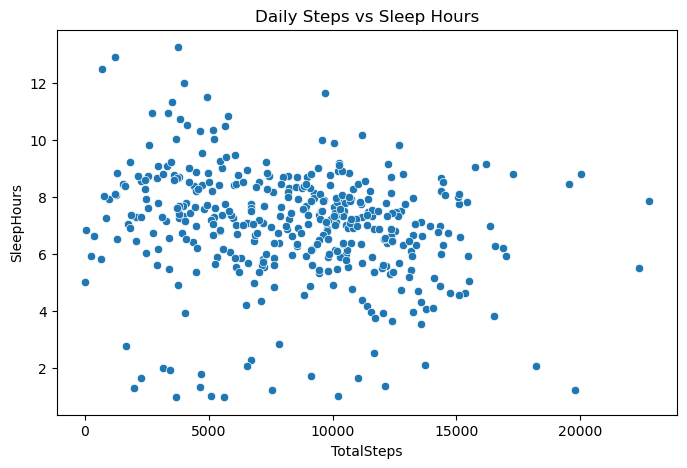

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data= merged, 
    x= 'TotalSteps', 
    y= 'SleepHours'
)
plt.title('Daily Steps vs Sleep Hours')
plt.show() # Display the plot

## Analysis 2: User Behaviour by day of week

## Which days are user most active?

In [28]:
steps_by_day = merged.groupby('DayOfWeek')['TotalSteps'].mean().round(0)
steps_by_day

DayOfWeek
Friday       7901.0
Monday       9273.0
Saturday     9871.0
Sunday       7298.0
Thursday     8184.0
Tuesday      9183.0
Wednesday    8023.0
Name: TotalSteps, dtype: float64

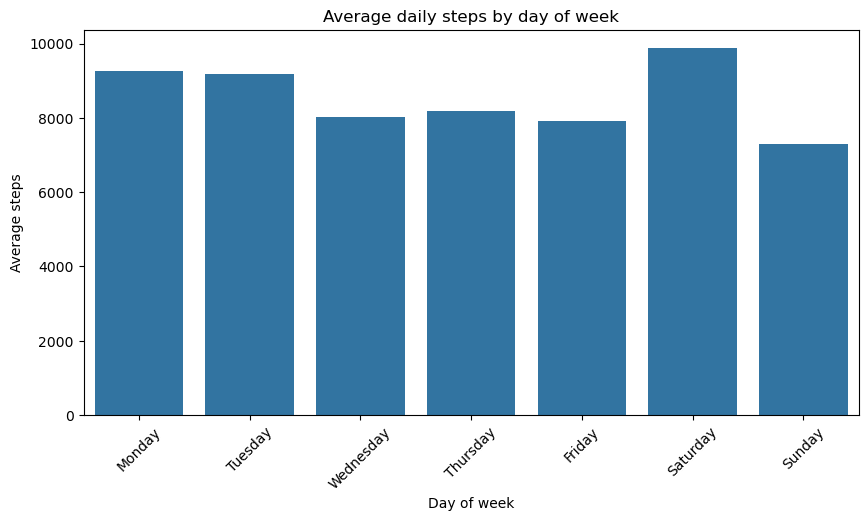

In [29]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

steps_day = merged.groupby('DayOfWeek')['TotalSteps'].mean().reindex(day_order)
plt.figure(figsize=(10,5))

sns.barplot(
    x= steps_day.index, 
    y = steps_day.values
)

plt.title('Average daily steps by day of week')
plt.ylabel('Average steps')
plt.xlabel('Day of week')

plt.xticks(rotation=45)  #use to rotate x axis tick labels by 45 degree
plt.show()

## Which days do users sleep the most?

In [30]:
sleep_by_day = merged.groupby('DayOfWeek')['SleepHours'].mean().round(2)
sleep_by_day

DayOfWeek
Friday       6.76
Monday       6.99
Saturday     6.99
Sunday       7.55
Thursday     6.69
Tuesday      6.74
Wednesday    7.25
Name: SleepHours, dtype: float64

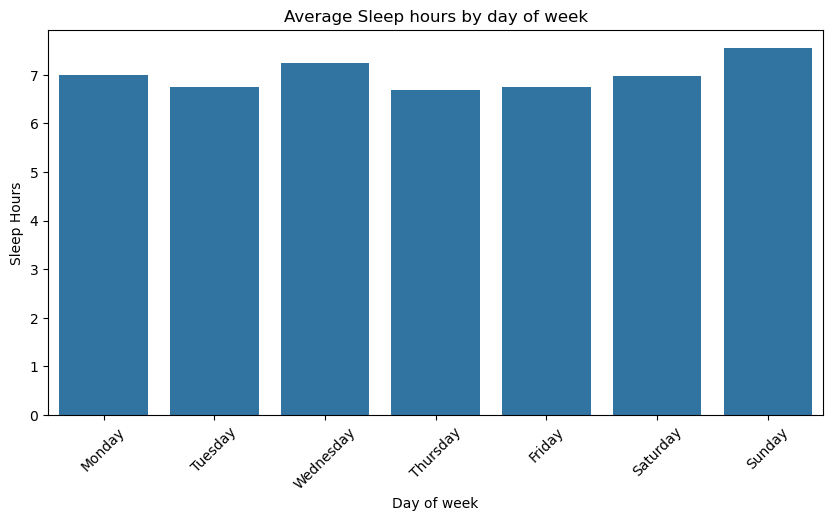

In [31]:
sleep_day = merged.groupby('DayOfWeek')['SleepHours'].mean().reindex(day_order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=sleep_day.index,
    y=sleep_day.values
)

plt.title('Average Sleep hours by day of week')
plt.ylabel('Sleep Hours')
plt.xlabel('Day of week')

plt.xticks(rotation= 45)

plt.show()

## Weekday vs Weekend 

In [34]:
 merged.groupby('IsWeekend')[['TotalSteps','SleepHours']].mean().round(2)

,TotalSteps,SleepHours
IsWeekend,,
False,8480.12,6.88
True,8607.46,7.26


## Sedentary Hours vs Sleep

In [35]:
merged['SedentaryHours'] = (merged['SedentaryMinutes']/60).round(2)

In [36]:
merged[['SedentaryHours','SleepHours']].corr()

,SedentaryHours,SleepHours
SedentaryHours,1.000000,-0.601109
SleepHours,-0.601109,1.000000


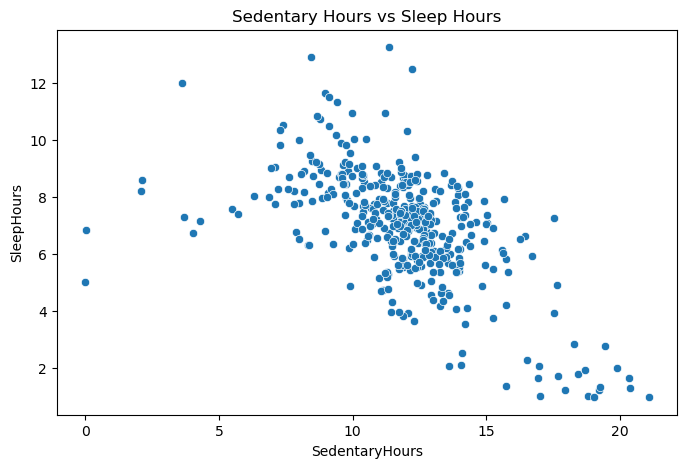

In [38]:
plt.figure(figsize= (8,5))
sns.scatterplot(
    data = merged, 
    x= 'SedentaryHours', 
    y = 'SleepHours'
)

plt.title('Sedentary Hours vs Sleep Hours')
plt.show()

In [39]:
merged[['SedentaryHours',
        'SleepHours']].describe().round(2)

,SedentaryHours,SleepHours
count,410.00,410.00
mean,11.87,6.99
std,2.77,1.98
min,0.00,0.97
25%,10.52,6.02
50%,11.95,7.21
75%,13.04,8.17
max,21.08,13.27


In [41]:
activity_level_pct = (merged['ActivityLevel'].value_counts(normalize= True).mul(100).round(2))
activity_level_pct

ActivityLevel
Highly Active        40.24
Moderately Active    36.34
Low Active           23.41
Name: proportion, dtype: float64

## Summary Tabels

In [44]:
#Day of week summary 
day_summary = merged.groupby('DayOfWeek').agg({

     'TotalSteps' : 'mean',
     'SleepHours' : 'mean',
     'SedentaryHours' : 'mean', 
     'Calories' : 'mean'
 }).round(2).reindex(day_order)

day_summary

,TotalSteps,SleepHours,SedentaryHours,Calories
DayOfWeek,,,,
Monday,9273.22,6.99,11.97,2431.98
Tuesday,9182.69,6.74,12.33,2496.20
Wednesday,8022.86,7.25,11.91,2378.24
Thursday,8183.52,6.69,11.64,2306.67
Friday,7901.40,6.76,12.38,2329.65
Saturday,9871.12,6.99,11.34,2506.89
Sunday,7297.85,7.55,11.46,2276.60


In [46]:
# Activity Level Summary
activity_summary = merged.groupby('ActivityLevel', observed=True).agg({
    'TotalSteps':'mean',
    'SleepHours':'mean',
    'SedentaryHours':'mean'
}).round(2)

activity_summary

,TotalSteps,SleepHours,SedentaryHours
ActivityLevel,,,
Low Active,3053.71,7.57,12.25
Moderately Active,7591.31,7.04,11.94
Highly Active,12526.38,6.60,11.58


In [47]:
# Weekend vs Weekdays Summary
weekend_summary = merged.groupby('IsWeekend').agg({
    'TotalSteps':'mean',
    'SleepHours':'mean',
    'SedentaryHours':'mean'
}).round(2)

weekend_summary

,TotalSteps,SleepHours,SedentaryHours
IsWeekend,,,
False,8480.12,6.88,12.04
True,8607.46,7.26,11.40


In [52]:
import os
os.makedirs(r'C:\Users\kusha\OneDrive\Desktop\My projects\BellaBeat case study\Analysis\summary tables', 
            exist_ok=True)

# Now save the files correctly
day_summary.to_csv(r'C:\Users\kusha\OneDrive\Desktop\My projects\BellaBeat case study\Analysis\summary tables\day_summary.csv', 
                   index=False)

activity_summary.to_csv(r'C:\Users\kusha\OneDrive\Desktop\My projects\BellaBeat case study\Analysis\summary tables\activity_summary.csv', 
                        index=False)

weekend_summary.to_csv(r'C:\Users\kusha\OneDrive\Desktop\My projects\BellaBeat case study\Analysis\summary tables\weekend_summary.csv', 
                       index=False)

merged.to_csv(r'C:\Users\kusha\OneDrive\Desktop\My projects\BellaBeat case study\Analysis\summary tables\bellabeat_cleaned.csv', 
              index=False)